# DS2002 · Data Cleaning (types, missing, duplicates)

**Lecture — 2026-09-21 · Fall 2026**  
**Class time:** 45 minutes

---

## Start with a real file and a wrong answer

Last week you learned what a DataFrame is and how to select, group, and join one. Every one of those exercises handed you data that already worked. Real files do not arrive that way, and the gap between those two facts is where most of a data job actually lives.

So we are going to open a real one right now — **25,562 transaction rows** from the Walmart export you will use for the midterm — ask it one simple question, and get an answer that is wrong by a factor of four. Then we will find out why, fix it properly, and save the result.

Three parts today:

1. **The wrong answer** — a real file, one question, and what the mess costs you.
2. **The mechanism** — the same five fixes on eight rows you can hold in your head.
3. **The real run** — those five fixes on all 25,562 rows, then saved to your Drive.

In [1]:
import pandas as pd

URL = ('https://raw.githubusercontent.com/jasontpv/DS2002FA26/main/'
       'notebooks/06-midterm-walmart/data/walmart_transactions.csv')

try:
    sales = pd.read_csv(URL)
    print('loaded over https from the course repo')
except Exception as err:
    # Dead wifi or a blocked URL. The same file is in the repo you cloned.
    print('URL failed:', err)
    sales = pd.read_csv('../06-midterm-walmart/data/walmart_transactions.csv')
    print('loaded from your local clone instead')

print(f'{len(sales):,} rows x {len(sales.columns)} columns')
sales.head(3)

loaded over https from the course repo
25,562 rows x 8 columns


,transaction_id,store_id,timestamp,sku,product_name,category,quantity,unit_price
0,TXN012636,FL-710,2024-09-13T09:48:13,PNUTBTR-16,PEANUT BUTTER,Grocery,1,3.15
1,TXN000759,fl-412,2024-09-02 20:30:20,CNSOUP-01,CANNED SOUP,GROCERY,1,2.02
2,TXN003338,FL-105,2024-09-06 10:06:00,TOILETPAPER12,Toilet Paper 12-Roll,Household Essentials,2,10.47


Stop and notice what that cell did. One line, one URL, and a spreadsheet's worth of data is in memory and queryable. No download, no Excel, no import wizard. That is the part of Pandas worth being impressed by — `read_csv` takes a path, a URL, or a string, and everything downstream works the same either way.

Now the inventory, the same three questions you ask of any new file.

In [2]:
print(sales.dtypes)
print()
print('missing values per column:')
print(sales.isna().sum())
print()
print('exact duplicate rows :', sales.duplicated().sum())
print('distinct categories  :', sales['category'].nunique())
print('distinct store_ids   :', sales['store_id'].nunique())

transaction_id      str
store_id            str
timestamp           str
sku                 str
product_name        str
category            str
quantity          int64
unit_price          str
dtype: object

missing values per column:
transaction_id      0
store_id            0
timestamp         886
sku                 0
product_name        0
category            0
quantity            0
unit_price          0
dtype: int64

exact duplicate rows : 30
distinct categories  : 37
distinct store_ids   : 60


Read those numbers as findings, not as noise:

- **`unit_price` is text.** Some rows wrote the price as `$4.76`. One dollar sign in a column of 25,000 numbers makes the whole column text, so `.sum()` would concatenate instead of add.
- **886 missing timestamps**, so anything time-based has a hole in it.
- **30 exact duplicate rows**, which inflate every total you compute.
- **37 distinct categories** in a store that does not have 37 departments.
- **60 distinct store IDs** for a chain with 36 stores.

Those last two are the interesting ones. Hold that thought and just ask the business question: which category brings in the most money?

In [3]:
# unit_price arrives as text on some rows, so convert just enough to add it up.
priced = sales.copy()
priced['unit_price'] = pd.to_numeric(
    priced['unit_price'].astype(str).str.replace('$', '', regex=False).str.strip(),
    errors='coerce')
priced['revenue'] = priced['quantity'] * priced['unit_price']

raw_rank = priced.groupby('category')['revenue'].sum().sort_values(ascending=False)
print('Top 8 categories by revenue, straight from the file:')
print(raw_rank.head(8).round(2))

Top 8 categories by revenue, straight from the file:
category
EMERGENCY             37947.92
Emergency Supplies    37940.54
emergency             37821.70
Emergency             36868.89
electronics           28398.82
ELECTRONICS           28124.14
Electronics           28071.13
baby                  22098.32
Name: revenue, dtype: float64


Look at that top-8 list before you read on.

`EMERGENCY`, `Emergency Supplies`, `emergency`, and `Emergency` are the top four results. They are the same category, counted four times, and every one of them lands around \$37,000. Then `electronics` shows up three more times just below.

If you pasted this into a slide, you would tell a manager that emergency supplies are worth about \$38,000 and roughly tied with electronics. Both halves of that sentence are wrong, and nothing in the output looks broken. That is what makes it dangerous — there is no error message, just a confident wrong number.

Here is the fix. Two string operations and a mapping for the judgment calls.

In [4]:
# Two string operations, then one mapping for the judgment calls.
CATEGORY_ROLLUP = {
    'alcoholic beverages': 'alcohol',
    'baby products': 'baby',
    'breakfast foods': 'breakfast',
    'emergency supplies': 'emergency',
    'games & entertainment': 'entertainment',
    'groceries': 'grocery',
    'health & wellness': 'health',
    'household essentials': 'household',
}

tidy = priced.copy()
tidy['category'] = tidy['category'].str.strip().str.lower().replace(CATEGORY_ROLLUP)
clean_rank = tidy.groupby('category')['revenue'].sum().sort_values(ascending=False)

print(f'categories: {raw_rank.size} -> {clean_rank.size}')
print()
print(clean_rank.round(2))
print()
print(f'Top category: ${raw_rank.iloc[0]:,.2f} before -> ${clean_rank.iloc[0]:,.2f} after')

categories: 37 -> 10

category
emergency        150579.05
baby              84709.61
electronics       84594.09
entertainment     52061.22
alcohol           48929.81
household         31966.04
health            27316.89
breakfast         18063.37
snacks            17473.87
grocery           16299.81
Name: revenue, dtype: float64

Top category: $37,947.92 before -> $150,579.05 after


The top category was never \$38,000. It is **\$150,579** — four times larger — and it is not close to electronics at all. Thirty-seven categories were always ten.

Nothing about the data changed. No rows were added, no prices corrected. Two string operations changed the answer to the only question anybody asked.

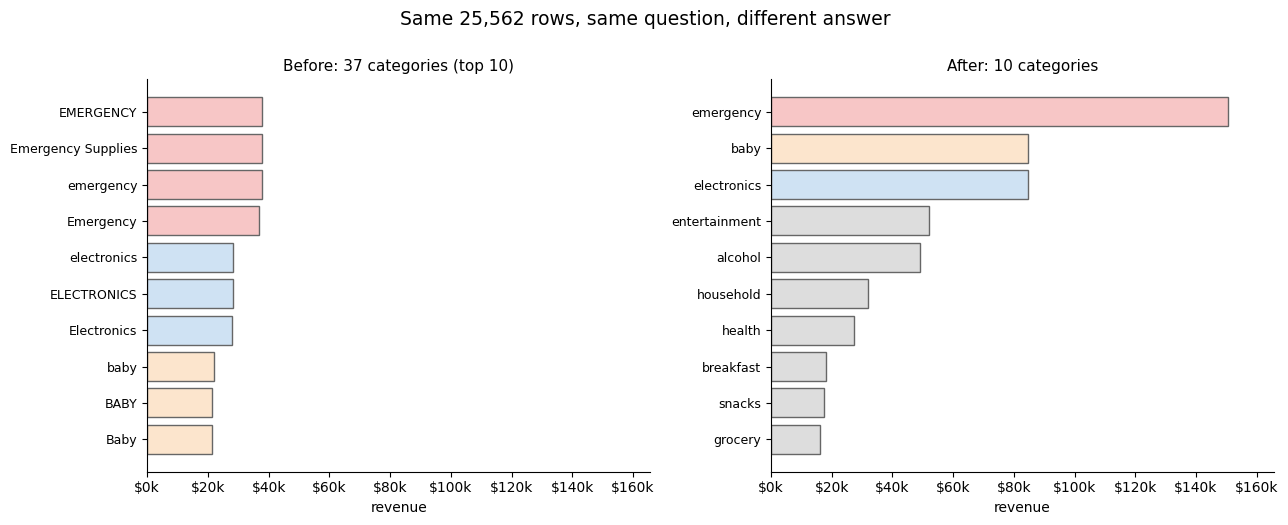

In [5]:
import matplotlib.pyplot as plt

# Colour the three families that got split, so you can see them fragment.
FAM = {'emergency': '#f7c6c6', 'electronics': '#cfe2f3', 'baby': '#fce5cd'}

def tint(name):
    key = str(name).strip().lower()
    return FAM.get(CATEGORY_ROLLUP.get(key, key), '#dddddd')

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for ax, series, title in [
    (axes[0], raw_rank.head(10)[::-1], f'Before: {raw_rank.size} categories (top 10)'),
    (axes[1], clean_rank[::-1], f'After: {clean_rank.size} categories'),
]:
    ax.barh(range(len(series)), series.values,
            color=[tint(c) for c in series.index], edgecolor='0.4')
    ax.set_yticks(range(len(series)))
    ax.set_yticklabels(series.index, fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('revenue')
    ax.set_xlim(0, clean_rank.max() * 1.1)
    ax.spines[['top', 'right']].set_visible(False)
    ax.xaxis.set_major_formatter(lambda x, p: f'${x/1000:.0f}k')
fig.suptitle(f'Same {len(sales):,} rows, same question, different answer',
             fontsize=13.5, y=1.0)
fig.tight_layout()
plt.show()

That picture is the argument for this whole hour. On the left, the real signal is shattered into four pink bars that each look unremarkable. On the right it is one bar that dwarfs everything else and obviously deserves attention.

**This is why cleaning is not the boring part.** It is not tidying up before the real work — it *is* the work, because it determines what the answer is. And the reason it takes two lines instead of two days is Pandas: `.str.lower()` applied to 25,562 rows is the same keystroke as applying it to one.

Now we slow down. You just saw one fix land; there are five, they have an order, and the order matters. We will learn them on eight rows where you can see every change, then come back and run the whole sequence on this file.

---

## Part 2 — the mechanism, on eight rows

Surveys of working data scientists put the share of time spent on cleaning somewhere north of half, and the reason is not that it is tedious. It is that **cleaning decisions change answers**, which you just watched happen.

Eight rows now, on purpose. At 25,562 rows you cannot tell whether a fix did what you meant; at eight you can read every value before and after. Same five fixes, same order, small enough to verify by eye.

This little file has every problem the big one has, plus a couple more.

In [6]:
import pandas as pd, numpy as np
from io import StringIO
raw = '''order_id,item,category,qty,price,ts
1,Cheeseburger,Food,2,$7.50,2026-09-05T12:03:00
1,Cheeseburger,Food,2,$7.50,2026-09-05T12:03:00
2,cheese burger,food,1,7.5,09/05/2026 12:40
3,Foam Finger,Merch,NULL,12,2026-09-05 13:00:00
4,UVA T-Shirt ,Apparel,2,$24.00,2026-09-05 13:05
5,Rain Poncho,RainGear,-3,6,2026-09-05T13:20:00
6,rain poncho,rain-gear,4,$6.00,
7,,Merch,1,12,2026-09-05T14:00:00'''
df = pd.read_csv(StringIO(raw))
df

,order_id,item,category,qty,price,ts
0,1,Cheeseburger,Food,2.0,$7.50,2026-09-05T12:03:00
1,1,Cheeseburger,Food,2.0,$7.50,2026-09-05T12:03:00
2,2,cheese burger,food,1.0,7.5,09/05/2026 12:40
3,3,Foam Finger,Merch,NaN,12,2026-09-05 13:00:00
4,4,UVA T-Shirt,Apparel,2.0,$24.00,2026-09-05 13:05
5,5,Rain Poncho,RainGear,-3.0,6,2026-09-05T13:20:00
6,6,rain poncho,rain-gear,4.0,$6.00,NaN
7,7,NaN,Merch,1.0,12,2026-09-05T14:00:00


### Take inventory before you touch anything

Three commands, every time, in this order. They tell you what kind of mess you have before you start guessing.

In [7]:
print('shape:', df.shape)
print()
print(df.dtypes)
print()
print('nulls per column:')
print(df.isnull().sum())
print()
print('exact duplicate rows:', df.duplicated().sum())

shape: (8, 6)

order_id      int64
item            str
category        str
qty         float64
price           str
ts              str
dtype: object

nulls per column:
order_id    0
item        1
category    0
qty         1
price       0
ts          1
dtype: int64

exact duplicate rows: 1


Read what those are telling you. `qty` and `price` came in as `object`, which means **text** — so the file contains something non-numeric in both columns. There is one null in `item` and one in `ts`. And one row is an exact duplicate of another.

Before the fixes, write down the number you are trying to get right. Otherwise you have no way to tell whether cleaning helped.

In [8]:
# The question: how much revenue did we take, and how many units moved?
# We cannot even compute it yet -- price is text. That is itself the first finding.
print(df['price'].tolist())
print(df['qty'].tolist())

['$7.50', '$7.50', '7.5', '12', '$24.00', '6', '$6.00', '12']
[2.0, 2.0, 1.0, nan, 2.0, -3.0, 4.0, 1.0]


### Fix 1 — duplicates, and which kind you mean

`drop_duplicates()` removes rows identical across **every** column. That is the safe version and it is what we want here: rows 0 and 1 are the same transaction exported twice.

In [9]:
clean = df.drop_duplicates().copy()
print('rows:', len(df), '->', len(clean))

rows: 8 -> 7


Be careful with the other kind. `drop_duplicates(subset=['order_id'])` keeps one row per order id — which is right if ids should be unique, and destroys your data if an order can legitimately have several line items. Look before you choose.

In [10]:
# Here, order_id 1 appeared twice because of the double export -- already handled.
# But note what subset= would do if orders had multiple items each:
print('unique order_ids:', clean['order_id'].nunique(), 'of', len(clean), 'rows')

unique order_ids: 7 of 7 rows


### Fix 2 — numbers that arrived as text

`price` has dollar signs. Strip them and convert. Real files also bring commas (`'1,240.00'`) and parentheses for negatives (`'(45.00)'`), so build the habit of stripping everything that is not part of a number.

In [11]:
clean['price'] = (clean['price'].astype(str)
                  .str.replace('$', '', regex=False)
                  .str.replace(',', '', regex=False)
                  .str.strip()
                  .astype(float))
print(clean['price'].dtype)
clean[['order_id', 'item', 'price']]

float64


,order_id,item,price
0,1,Cheeseburger,7.5
2,2,cheese burger,7.5
3,3,Foam Finger,12.0
4,4,UVA T-Shirt,24.0
5,5,Rain Poncho,6.0
6,6,rain poncho,6.0
7,7,NaN,12.0


### Fix 3 — coercion, and the decision it forces

`qty` contains the string `'NULL'`. `astype(int)` would just crash. `pd.to_numeric` with `errors='coerce'` turns anything unparseable into `NaN` — which does not solve the problem, it *surfaces* it. Now you have to decide what a missing quantity means.

In [12]:
clean['qty'] = pd.to_numeric(clean['qty'], errors='coerce')
print(clean[['order_id', 'item', 'qty']])
print()
print('missing qty:', clean['qty'].isna().sum())
print('negative qty:', (clean['qty'] < 0).sum())

   order_id           item  qty
0         1   Cheeseburger  2.0
2         2  cheese burger  1.0
3         3    Foam Finger  NaN
4         4   UVA T-Shirt   2.0
5         5    Rain Poncho -3.0
6         6    rain poncho  4.0
7         7            NaN  1.0

missing qty: 1
negative qty: 1


Two separate problems, two separate decisions:

**Missing quantity.** Dropping the row loses a real sale. Filling with 1 invents data. Filling with the median invents data and hides it. Here, dropping is defensible because one row of eight is a small, reportable loss — but you report it.

**Negative quantity.** A `-3` is almost certainly a refund. Whether it belongs in your total depends on the question: gross units sold excludes it, net revenue includes it. State which one you are computing.

The rule for the whole course: **record the decision, and record how many rows it touched.** A cleaning step with no row count is not reviewable.

In [13]:
before = len(clean)
dropped_missing = clean['qty'].isna().sum()
dropped_negative = (clean['qty'] < 0).sum()

clean = clean[clean['qty'].notna() & (clean['qty'] > 0)].copy()
clean['qty'] = clean['qty'].astype(int)

print(f'dropped {dropped_missing} row(s) with no quantity')
print(f'dropped {dropped_negative} refund row(s) -- computing GROSS units')
print(f'rows: {before} -> {len(clean)}')

dropped 1 row(s) with no quantity
dropped 1 refund row(s) -- computing GROSS units
rows: 7 -> 5


### Fix 4 — text that means the same thing

`Food` and `food`. `RainGear` and `rain-gear`. `Apparel` that is really merch. To a computer these are four or five distinct categories, so every group-by is fragmented and every chart has duplicate bars.

Lowercase and strip first, then map the remaining variants explicitly.

In [14]:
print('before:', sorted(clean['category'].unique()))

clean['category'] = (clean['category'].str.strip().str.lower()
                     .str.replace('-', '', regex=False))
print('after normalizing case and punctuation:', sorted(clean['category'].unique()))

before: ['Apparel', 'Food', 'Merch', 'food', 'rain-gear']
after normalizing case and punctuation: ['apparel', 'food', 'merch', 'raingear']


Case and punctuation get you most of the way. The rest is a business decision that no amount of string handling can make for you: is `apparel` the same category as `merch`? Somebody has to answer that, and the mapping is where you write the answer down.

In [15]:
CATEGORY_MAP = {
    'apparel': 'merch',      # decision: apparel rolls up into merch
    'raingear': 'raingear',
}
clean['category'] = clean['category'].replace(CATEGORY_MAP)
print('final categories:', sorted(clean['category'].unique()))
print()
print(clean['category'].value_counts())

final categories: ['food', 'merch', 'raingear']

category
food        2
merch       2
raingear    1
Name: count, dtype: int64


Do the same for `item`, where the same product is written two ways.

In [16]:
print('before:', sorted(clean['item'].dropna().unique()))

clean['item'] = clean['item'].str.strip().str.title()
ITEM_MAP = {'Cheese Burger': 'Cheeseburger'}
clean['item'] = clean['item'].replace(ITEM_MAP)
print('after: ', sorted(clean['item'].dropna().unique()))

before: ['Cheeseburger', 'UVA T-Shirt ', 'cheese burger', 'rain poncho']
after:  ['Cheeseburger', 'Rain Poncho', 'Uva T-Shirt']


### Fix 5 — dates in four formats

This column has ISO timestamps, a US-style `09/05/2026 12:40`, a date with no seconds, and one empty cell. `pd.to_datetime` with `format='mixed'` handles the variety, and `errors='coerce'` turns the unparseable ones into `NaT` instead of raising.

In [17]:
clean['ts'] = pd.to_datetime(clean['ts'], errors='coerce', format='mixed')
print(clean['ts'].dtype)
print('unparseable timestamps (NaT):', clean['ts'].isna().sum())
clean[['order_id', 'item', 'ts']]

datetime64[us]
unparseable timestamps (NaT): 1


,order_id,item,ts
0,1,Cheeseburger,2026-09-05 12:03:00
2,2,Cheeseburger,2026-09-05 12:40:00
4,4,Uva T-Shirt,2026-09-05 13:05:00
6,6,Rain Poncho,NaT
7,7,NaN,2026-09-05 14:00:00


A real datetime column is what makes the next month of this course possible: you cannot group by hour, join to daily weather, or plot a time series against a text column.

The `NaT` row is a decision again. Keep it if you only need totals; drop it if you are doing anything time-based, because a row with no timestamp cannot be placed on a timeline.

In [18]:
clean['hour'] = clean['ts'].dt.hour
clean[['order_id', 'item', 'ts', 'hour']]

,order_id,item,ts,hour
0,1,Cheeseburger,2026-09-05 12:03:00,12.0
2,2,Cheeseburger,2026-09-05 12:40:00,12.0
4,4,Uva T-Shirt,2026-09-05 13:05:00,13.0
6,6,Rain Poncho,NaT,NaN
7,7,NaN,2026-09-05 14:00:00,14.0


### Prove it, then measure what changed

State what must now be true. If an assertion fails, you learn it here instead of in a chart three cells later.

In [19]:
assert clean.duplicated().sum() == 0, 'duplicates remain'
assert clean['price'].dtype == float, 'price is not numeric'
assert clean['qty'].min() >= 1, 'non-positive quantities remain'
assert pd.api.types.is_datetime64_any_dtype(clean['ts']), 'ts is not a datetime'
assert clean['category'].str.islower().all(), 'inconsistent category text'
print('clean:', clean.shape)

clean: (5, 7)


Now the part that justifies the whole session. Compute the answer the naive way and the clean way, and look at the gap.

In [20]:
clean['revenue'] = clean['qty'] * clean['price']

naive_rows = len(df)
naive_units = pd.to_numeric(df['qty'], errors='coerce').fillna(0).sum()
naive_categories = df['category'].nunique()

print(f'rows:        {naive_rows} raw -> {len(clean)} clean')
print(f'units:       {naive_units:.0f} raw -> {clean["qty"].sum()} clean')
print(f'categories:  {naive_categories} raw -> {clean["category"].nunique()} clean')
print(f'revenue:     ${clean["revenue"].sum():.2f} (not computable before cleaning)')

rows:        8 raw -> 5 clean
units:       9 raw -> 10 clean
categories:  6 raw -> 3 clean
revenue:     $106.50 (not computable before cleaning)


Six apparent categories collapse to three. That is the difference between a chart with six confusing bars and one a manager can read.

### The order matters

This sequence is not arbitrary — each step depends on the last:

1. **Duplicates first.** Cheaper to fix five rows than to fix six and then delete one.
2. **Types next.** You cannot filter on `qty > 0` while `qty` is text.
3. **Then missing and out-of-range values**, now that comparisons work.
4. **Then text normalization**, so each group collects every row that belongs to it.
5. **Then dates**, so anything time-based becomes possible.
6. **Then assert**, so the next person can trust it.

---

## Part 3 — the same six steps on all 25,562 rows

Nothing new below. It is the identical sequence you just did by eye, pointed at the real file, and it is worth seeing that the code barely changes when the data gets 3,000 times bigger.

What *does* change is how you know it worked. At eight rows you looked. At 25,562 you cannot, so **the printed row counts are your eyes** — every step reports what it touched, and a number that surprises you is a bug you just caught.

In [21]:
sales_clean = sales.drop_duplicates().copy()
print(f'1. duplicates    : {len(sales):,} -> {len(sales_clean):,}')

sales_clean['unit_price'] = pd.to_numeric(
    sales_clean['unit_price'].astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip(), errors='coerce')
print(f'2. price to float: {sales_clean["unit_price"].isna().sum()} still unparseable')

before = len(sales_clean)
refunds = (sales_clean['quantity'] < 0).sum()
sales_clean = sales_clean[sales_clean['quantity'] > 0].copy()
print(f'3. dropped {refunds} refund rows (GROSS): {before:,} -> {len(sales_clean):,}')

cats, stores = sales_clean['category'].nunique(), sales_clean['store_id'].nunique()
sales_clean['category'] = sales_clean['category'].str.strip().str.lower().replace(CATEGORY_ROLLUP)
sales_clean['store_id'] = sales_clean['store_id'].str.strip().str.upper()
print(f'4. categories {cats} -> {sales_clean["category"].nunique()} | '
      f'stores {stores} -> {sales_clean["store_id"].nunique()}')

sales_clean['timestamp'] = pd.to_datetime(sales_clean['timestamp'], errors='coerce', format='mixed')
print(f'5. dates parsed  : {sales_clean["timestamp"].isna().sum()} rows have no usable timestamp')

1. duplicates    : 25,562 -> 25,532
2. price to float: 0 still unparseable
3. dropped 130 refund rows (GROSS): 25,532 -> 25,402
4. categories 37 -> 10 | stores 60 -> 36
5. dates parsed  : 881 rows have no usable timestamp


Read the receipts. 30 duplicate rows gone, every price now numeric, 130 refunds set aside (so this is **gross**, and we said so), 37 categories collapsed to 10, 60 store IDs to 36.

The last line is the one to sit with: **881 rows have no usable timestamp.** We did not silently drop them and we did not invent dates for them. They are fine for a revenue total and useless for anything hour-by-hour, and the number goes in your writeup either way. A cleaning step with no row count is not reviewable.

In [22]:
assert sales_clean.duplicated().sum() == 0
assert sales_clean['unit_price'].notna().all()
assert (sales_clean['quantity'] > 0).all()
assert pd.api.types.is_datetime64_any_dtype(sales_clean['timestamp'])
assert sales_clean['category'].str.islower().all()

sales_clean['revenue'] = sales_clean['quantity'] * sales_clean['unit_price']

print(f'rows      : {len(sales):,} raw -> {len(sales_clean):,} clean')
print(f'categories: {sales["category"].nunique()} raw -> {sales_clean["category"].nunique()} clean')
print(f'stores    : {sales["store_id"].nunique()} raw -> {sales_clean["store_id"].nunique()} clean')
print(f'revenue   : ${sales_clean["revenue"].sum():,.2f}')
print()
print(sales_clean.groupby('category')['revenue'].sum().sort_values(ascending=False).round(2))
print()
print('busiest hour of the day:', int(sales_clean['timestamp'].dt.hour.mode()[0]))

rows      : 25,562 raw -> 25,402 clean
categories: 37 raw -> 10 clean
stores    : 60 raw -> 36 clean
revenue   : $534,070.16

category
emergency        151276.83
baby              85002.54
electronics       84926.99
entertainment     52251.39
alcohol           48982.13
household         32071.94
health            27555.24
breakfast         18129.76
snacks            17543.70
grocery           16329.64
Name: revenue, dtype: float64

busiest hour of the day: 10


Half a million dollars across 25,402 rows, a category ranking you can defend, and `timestamp` is now a real datetime — which is what makes `.dt.hour` work, and what will let you join this to weather data on the midterm. None of that was possible twenty minutes ago on the same file.

The five `assert` lines above are the habit worth stealing. They cost one cell and they turn "I think it is clean" into something the notebook checks every time it runs.

---

## Clean once, save it, never clean it again

That work took real effort. Do not make yourself redo it every time the runtime restarts — and on Colab it *will* restart, because anything you write to `/content` is deleted when your session ends. Your notebook survives because it lives in Drive. Your data files do not, unless you put them there too.

So mount Drive, define one folder, and build every path from it.

In [23]:
from pathlib import Path

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')          # asks you to authorize, once per session
    DATA_DIR = Path('/content/drive/MyDrive/DS2002/data')
else:
    # Not on Colab: a scratch folder that does NOT survive. Same variable
    # name, so nothing below has to care where it is writing.
    import tempfile
    DATA_DIR = Path(tempfile.gettempdir()) / 'ds2002-data'

DATA_DIR.mkdir(parents=True, exist_ok=True)

out = DATA_DIR / 'walmart_clean.csv'
sales_clean.to_csv(out, index=False)

assert out.exists(), f'save failed: {out}'
print('saved to :', out)
print('size     :', f'{out.stat().st_size:,} bytes')

# Read it back. 'I thought it saved' is not a recoverable position.
check = pd.read_csv(out)
print('rows back:', f'{len(check):,}')

saved to : /var/folders/h4/4rnnhgr11s3b_06kp9v6l7rm0000gn/T/ds2002-data/walmart_clean.csv
size     : 2,198,436 bytes
rows back: 25,402


Three habits in that cell, all worth keeping:

- **`DATA_DIR` defined once**, so every later path is `DATA_DIR / 'something.csv'` and moving the folder is a one-line change.
- **`mkdir(parents=True, exist_ok=True)`** before writing, because `to_csv` will not create a missing folder for you.
- **Read it back and check**, because "I thought it saved" is not a recoverable position the night before a deadline.

You re-authorize the Drive mount once per session. That is normal and unavoidable.

Next time you need this data you call `pd.read_csv(DATA_DIR / 'walmart_clean.csv')` and start working immediately. For the full treatment — uploads, downloads, zipping a folder, timestamped saves, and every gotcha — see **`notebooks/10-Reference/Colab File Persistence and Google Drive — Reference.ipynb`**.

Wednesday you run this whole sequence yourself, and Friday you run it on a file where you cannot eyeball the answer.

### Practice 1 — revenue by category

Using `clean`, print revenue per category, highest first. Which category would you tell the vendor to stock more of?

In [ ]:
# TODO

### Practice 2 — the refund question

We dropped the refund row and called the result gross units. Recompute **net** units and net revenue with the refund included, starting again from `df`. How much does the answer move, and which number would you put in front of a manager?

In [ ]:
# TODO: start from df, repeat the cleaning, but keep negative quantities

**Which number, and why:** _..._